1. Title and objective

# CICIoMT2024 - Explainability and Final Model Selection

## Objective
This notebook consolidates the main results of the project, compares the best-performing models across the binary, grouped multiclass, and full multiclass tasks, and applies model explainability techniques to the strongest Random Forest models.

The notebook focuses on:
- final model comparison across tasks
- feature importance analysis
- permutation importance
- SHAP-based global interpretation
- selected local prediction explanations
- final recommendations for deployment and portfolio presentation

2. Imports

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix

3. Display settings

In [3]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

plt.style.use("default")
sns.set_theme(style="whitegrid")

4. Load saved results and models

## Load saved reports and trained models
This notebook assumes that the Random Forest models and their result files have already been saved from the modeling notebooks.

In [4]:
REPORT_DIR = Path("../reports/results")
MODEL_DIR = Path("../models")
PROCESSED_DIR = Path("../data/processed")

In [5]:
binary_results = pd.read_csv(REPORT_DIR / "binary_model_comparison.csv")
grouped_results = pd.read_csv(REPORT_DIR / "grouped_multiclass_model_comparison.csv")
full_results = pd.read_csv(REPORT_DIR / "full_multiclass_model_comparison.csv")

binary_rf_importance = pd.read_csv(REPORT_DIR / "binary_random_forest_importance.csv")
grouped_rf_importance = pd.read_csv(REPORT_DIR / "grouped_multiclass_rf_importance.csv")
full_rf_importance = pd.read_csv(REPORT_DIR / "full_multiclass_rf_importance.csv")

binary_model = joblib.load(MODEL_DIR / "binary_random_forest.joblib")
grouped_model = joblib.load(MODEL_DIR / "grouped_random_forest.joblib")
full_model = joblib.load(MODEL_DIR / "full_random_forest.joblib")

5. Load datasets used for explanation

In [6]:
X_test_binary = pd.read_csv(PROCESSED_DIR / "X_test_tree_binary.csv")
y_test_binary = pd.read_csv(PROCESSED_DIR / "y_test_binary.csv").squeeze("columns")

X_test_grouped = pd.read_csv(PROCESSED_DIR / "X_test_tree_grouped.csv")
y_test_grouped = pd.read_csv(PROCESSED_DIR / "y_test_grouped.csv").squeeze("columns")

X_test_full = pd.read_csv(PROCESSED_DIR / "X_test_tree_full.csv")
y_test_full = pd.read_csv(PROCESSED_DIR / "y_test_full.csv").squeeze("columns")

print("Binary test:", X_test_binary.shape, y_test_binary.shape)
print("Grouped test:", X_test_grouped.shape, y_test_grouped.shape)
print("Full test:", X_test_full.shape, y_test_full.shape)

Binary test: (677063, 73) (677063,)
Grouped test: (677063, 73) (677063,)
Full test: (677063, 73) (677063,)


6. Load label mappings

In [7]:
grouped_mapping = pd.read_csv(REPORT_DIR / "grouped_label_mapping.csv")
full_mapping = pd.read_csv(REPORT_DIR / "full_label_mapping.csv")

grouped_class_names = grouped_mapping.sort_values("grouped_class_code")["grouped_class_name"].tolist()
full_class_names = full_mapping.sort_values("full_class_code")["full_class_name"].tolist()

print("Grouped classes:", grouped_class_names)
print("Full classes:", full_class_names)

Grouped classes: ['Benign', 'DDoS', 'DoS', 'MQTT Attack', 'Recon', 'Spoofing']
Full classes: ['Benign Traffic', 'DDoS ICMP Flood', 'DDoS UDP Flood', 'DoS ICMP Flood', 'DoS TCP Flood', 'DoS UDP Flood', 'MITM ARP Spoofing', 'MQTT DDoS Publish Flood', 'MQTT DoS Connect Flood', 'MQTT DoS Publish Flood', 'MQTT Malformed', 'Recon OS Scan', 'Recon Ping Sweep', 'Recon Port Scan', 'Recon Vulnerability Scan']


7. Final metric comparison across tasks

## Final metric comparison across tasks
This section compares the strongest model from each task.

In [32]:
best_binary = binary_results.sort_values(["f1", "pr_auc", "roc_auc"], ascending=False).head(1).copy()
best_grouped = grouped_results.sort_values(["macro_f1", "weighted_f1", "accuracy"], ascending=False).head(1).copy()
best_full = full_results.sort_values(["macro_f1", "weighted_f1", "accuracy"], ascending=False).head(1).copy()

best_binary["task"] = "Binary"
best_grouped["task"] = "Grouped Multiclass"
best_full["task"] = "Full Multiclass"

best_binary

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,task
0,Random Forest,0.99936,0.999763,0.999591,0.999677,0.999796,0.999997,Binary


In [33]:
cross_task_summary = pd.concat([best_binary, best_grouped, best_full], ignore_index=True, sort=False)
cross_task_summary

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,task,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.999360,0.999763,0.999591,0.999677,0.999796,0.999997,Binary,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,0.998136,NaN,NaN,NaN,NaN,NaN,Grouped Multiclass,0.901105,0.836679,0.859609,0.998101,0.998136,0.998084
2,Random Forest,0.985746,NaN,NaN,NaN,NaN,NaN,Full Multiclass,0.848435,0.734346,0.778298,0.985044,0.985746,0.985076


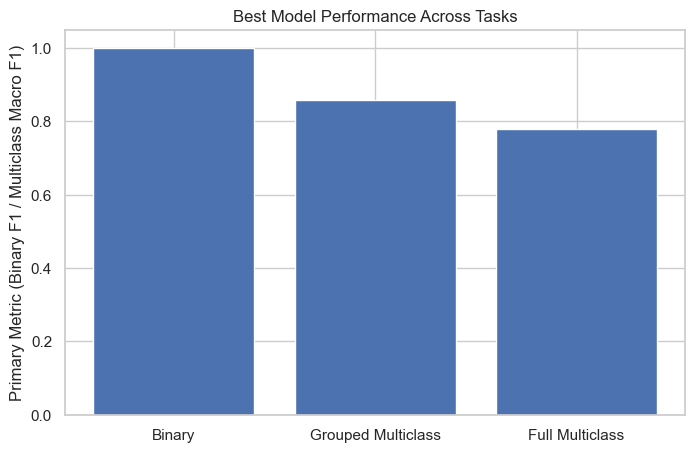

In [34]:
plt.figure(figsize=(8, 5))
plot_df = cross_task_summary.copy()
plot_df["primary_metric"] = [
    plot_df.loc[plot_df["task"] == "Binary", "f1"].values[0],
    plot_df.loc[plot_df["task"] == "Grouped Multiclass", "macro_f1"].values[0],
    plot_df.loc[plot_df["task"] == "Full Multiclass", "macro_f1"].values[0],
]
plt.bar(plot_df["task"], plot_df["primary_metric"])
plt.title("Best Model Performance Across Tasks")
plt.ylabel("Primary Metric (Binary F1 / Multiclass Macro F1)")
plt.show()

8. Compare top features across tasks

## Compare top Random Forest features across tasks

In [35]:
binary_top = binary_rf_importance.head(10).copy()
binary_top["task"] = "Binary"

grouped_top = grouped_rf_importance.head(10).copy()
grouped_top["task"] = "Grouped"

full_top = full_rf_importance.head(10).copy()
full_top["task"] = "Full"

combined_top_features = pd.concat([binary_top, grouped_top, full_top], ignore_index=True)
combined_top_features

,feature,importance,task
0,ACK Flag Count,0.082700,Binary
1,Packet Length Mean,0.079398,Binary
2,Packet Length Max,0.078927,Binary
3,Average Packet Size,0.071244,Binary
4,PSH Flag Count,0.064360,Binary
5,Fwd Packet Length Mean,0.061024,Binary
6,Subflow Fwd Bytes,0.054549,Binary
7,Fwd Segment Size Avg,0.044681,Binary
8,Total Length of Fwd Packet,0.039824,Binary
9,Fwd Seg Size Min,0.039038,Binary


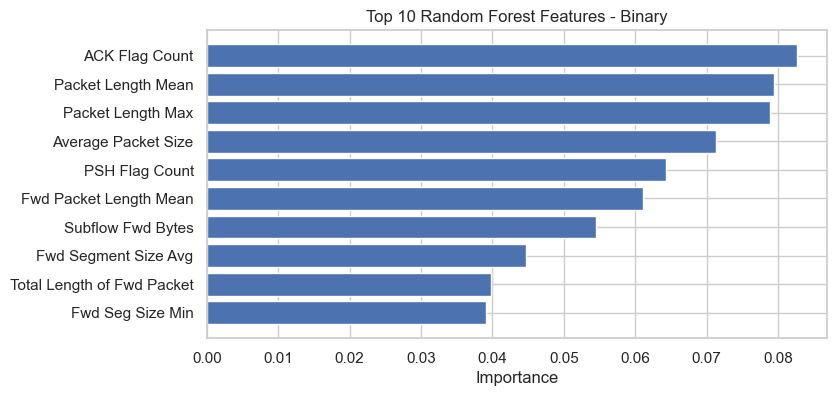

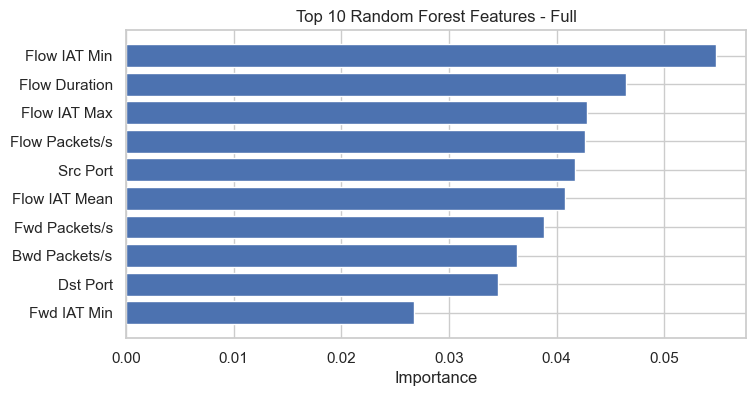

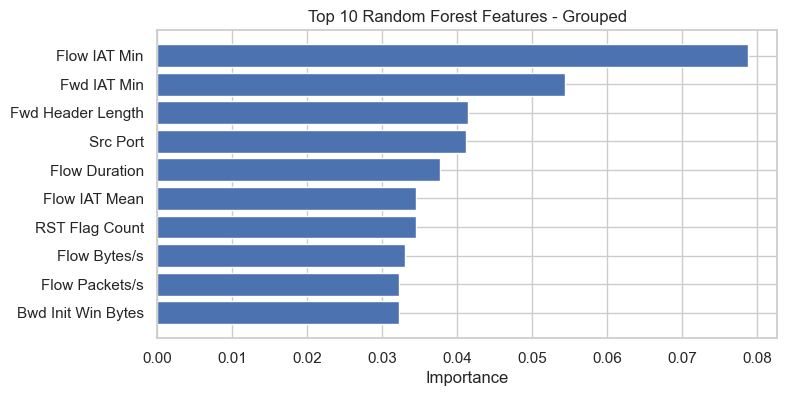

In [36]:
for task_name, task_df in combined_top_features.groupby("task"):
    plt.figure(figsize=(8, 4))
    temp = task_df.sort_values("importance")
    plt.barh(temp["feature"], temp["importance"])
    plt.title(f"Top 10 Random Forest Features - {task_name}")
    plt.xlabel("Importance")
    plt.show()

9. Final model-choice table

## Final model-selection table

In [37]:
final_selection_table = pd.DataFrame({
    "Task": ["Binary Detection", "Grouped Multiclass", "Full Multiclass"],
    "Selected Model": ["Random Forest", "Random Forest", "Random Forest"],
    "Main Reason": [
        "Highest F1, ROC-AUC, and PR-AUC with strong benign recognition",
        "Highest macro F1 and best balance across grouped attack families",
        "Highest macro F1 and strongest performance on fine-grained attack types"
    ],
    "Deployment Recommendation": [
        "Yes",
        "Yes",
        "Optional / advanced mode"
    ]
})

final_selection_table

,Task,Selected Model,Main Reason,Deployment Recommendation
0,Binary Detection,Random Forest,"Highest F1, ROC-AUC, and PR-AUC with strong be...",Yes
1,Grouped Multiclass,Random Forest,Highest macro F1 and best balance across group...,Yes
2,Full Multiclass,Random Forest,Highest macro F1 and strongest performance on ...,Optional / advanced mode


The final model-selection table shows that Random Forest was the most effective model family across all project tasks. However, the deployment role of each model differs. The binary Random Forest is best suited for the primary detection layer because it offers near-perfect benign-versus-attack discrimination. The grouped multiclass Random Forest is the most suitable follow-up classifier for operational use, since it provides strong attack-family identification with better robustness than the full attack-type model. The full multiclass Random Forest remains valuable, but is better positioned as an advanced analytical or forensic layer because fine-grained subtype classification is more affected by class imbalance and behavioural overlap.

10. Permutation importance - binary model

## Permutation importance - Binary Random Forest
Permutation importance provides a model-agnostic estimate of feature contribution.

In [21]:
binary_sample_n = min(50000, len(X_test_binary))
X_binary_sample = X_test_binary.sample(n=binary_sample_n, random_state=42)
y_binary_sample = y_test_binary.loc[X_binary_sample.index]

perm_binary = permutation_importance(
    binary_model,
    X_binary_sample,
    y_binary_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_binary_df = pd.DataFrame({
    "feature": X_binary_sample.columns,
    "importance_mean": perm_binary.importances_mean,
    "importance_std": perm_binary.importances_std
}).sort_values("importance_mean", ascending=False)

perm_binary_df.head(15)

,feature,importance_mean,importance_std
0,Src Port,0.005216,0.000175
2,Flow Duration,0.004064,0.000180
21,Fwd IAT Total,0.002788,0.000128
62,Bwd Init Win Bytes,0.002604,0.000175
35,Fwd Packets/s,0.001820,0.000181
25,Fwd IAT Min,0.001764,0.000053
61,FWD Init Win Bytes,0.001632,0.000190
26,Bwd IAT Total,0.001544,0.000020
36,Bwd Packets/s,0.001344,0.000064
16,Flow Packets/s,0.001308,0.000078


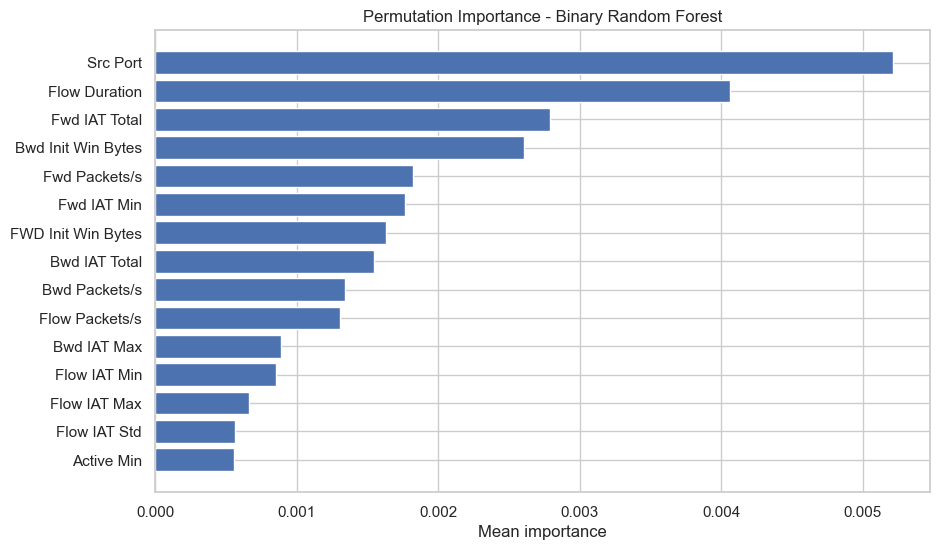

In [22]:
plt.figure(figsize=(10, 6))
temp = perm_binary_df.head(15).sort_values("importance_mean")
plt.barh(temp["feature"], temp["importance_mean"])
plt.title("Permutation Importance - Binary Random Forest")
plt.xlabel("Mean importance")
plt.show()

11. Permutation importance - grouped model

In [23]:
grouped_sample_n = min(50000, len(X_test_grouped))
X_grouped_sample = X_test_grouped.sample(n=grouped_sample_n, random_state=42)
y_grouped_sample = y_test_grouped.loc[X_grouped_sample.index]

perm_grouped = permutation_importance(
    grouped_model,
    X_grouped_sample,
    y_grouped_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_grouped_df = pd.DataFrame({
    "feature": X_grouped_sample.columns,
    "importance_mean": perm_grouped.importances_mean,
    "importance_std": perm_grouped.importances_std
}).sort_values("importance_mean", ascending=False)

perm_grouped_df.head(15)

,feature,importance_mean,importance_std
0,Src Port,0.002640,0.000200
1,Dst Port,0.000196,0.000023
62,Bwd Init Win Bytes,0.000088,0.000072
20,Flow IAT Min,0.000080,0.000022
44,RST Flag Count,0.000064,0.000029
15,Flow Bytes/s,0.000064,0.000015
24,Fwd IAT Max,0.000060,0.000042
6,Total Length of Bwd Packet,0.000052,0.000010
61,FWD Init Win Bytes,0.000048,0.000035
19,Flow IAT Max,0.000048,0.000027


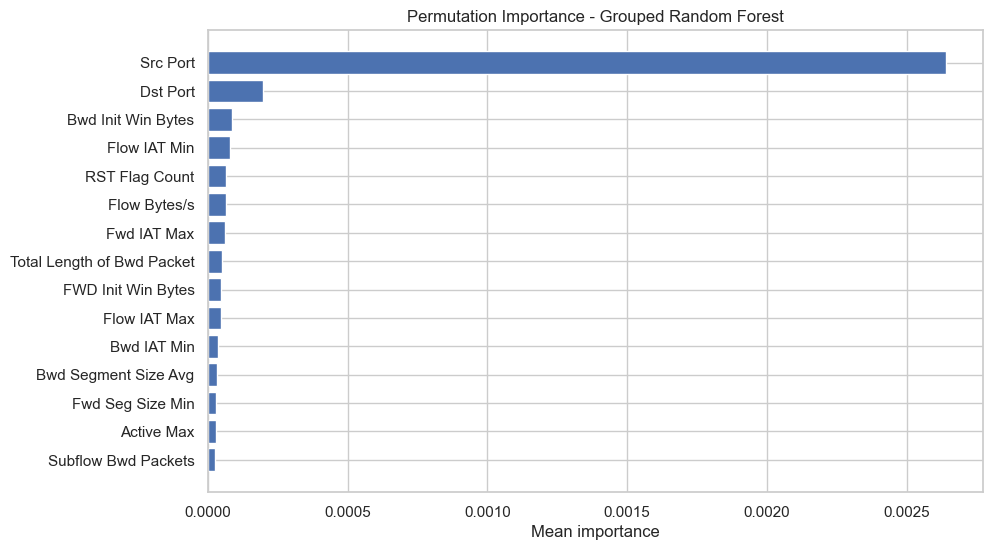

In [24]:
plt.figure(figsize=(10, 6))
temp = perm_grouped_df.head(15).sort_values("importance_mean")
plt.barh(temp["feature"], temp["importance_mean"])
plt.title("Permutation Importance - Grouped Random Forest")
plt.xlabel("Mean importance")
plt.show()

In [25]:
top_perm_summary = pd.DataFrame({
    "Binary top features": perm_binary_df.head(10)["feature"].tolist(),
    "Grouped top features": perm_grouped_df.head(10)["feature"].tolist()
})

top_perm_summary

,Binary top features,Grouped top features
0,Src Port,Src Port
1,Flow Duration,Dst Port
2,Fwd IAT Total,Bwd Init Win Bytes
3,Bwd Init Win Bytes,Flow IAT Min
4,Fwd Packets/s,RST Flag Count
5,Fwd IAT Min,Flow Bytes/s
6,FWD Init Win Bytes,Fwd IAT Max
7,Bwd IAT Total,Total Length of Bwd Packet
8,Bwd Packets/s,FWD Init Win Bytes
9,Flow Packets/s,Flow IAT Max


In [26]:
top_perm_summary.to_csv(REPORT_DIR / "top_permutation_features_summary.csv", index=False)

12. Permutation importance - full model

In [27]:
full_sample_n = min(10000, len(X_test_full))
X_full_sample = X_test_full.sample(n=full_sample_n, random_state=42)
y_full_sample = y_test_full.loc[X_full_sample.index]

perm_full = permutation_importance(
    full_model,
    X_full_sample,
    y_full_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=1
)

perm_full_df = pd.DataFrame({
    "feature": X_full_sample.columns,
    "importance_mean": perm_full.importances_mean,
    "importance_std": perm_full.importances_std
}).sort_values("importance_mean", ascending=False)

perm_full_df.head(15)

,feature,importance_mean,importance_std
1,Dst Port,0.018133,0.000544
19,Flow IAT Max,0.010567,0.000377
35,Fwd Packets/s,0.009100,0.000216
17,Flow IAT Mean,0.008900,0.000216
36,Bwd Packets/s,0.008133,0.000205
16,Flow Packets/s,0.007933,0.000205
0,Src Port,0.007833,0.001613
20,Flow IAT Min,0.007833,0.000411
2,Flow Duration,0.007667,0.000249
61,FWD Init Win Bytes,0.003133,0.000741


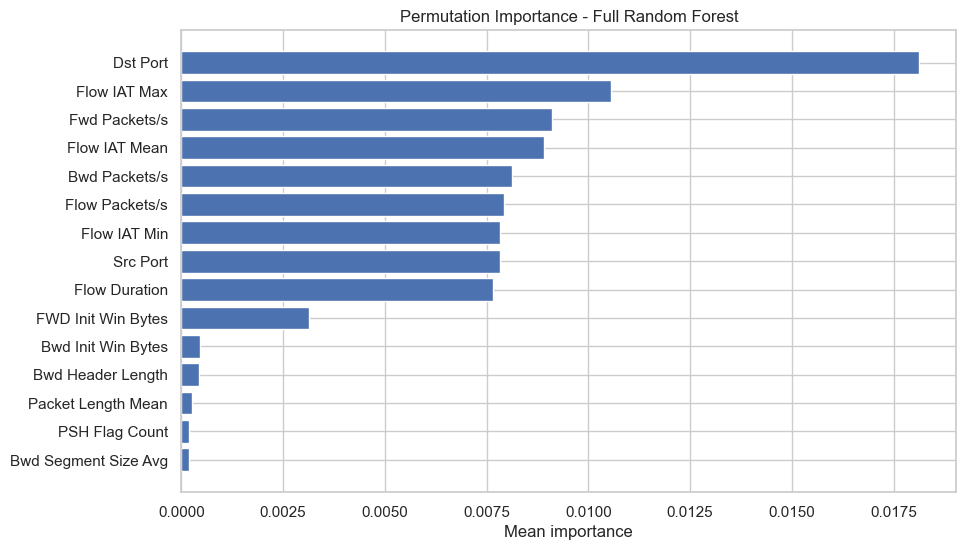

In [28]:
plt.figure(figsize=(10, 6))
temp = perm_full_df.head(15).sort_values("importance_mean")
plt.barh(temp["feature"], temp["importance_mean"])
plt.title("Permutation Importance - Full Random Forest")
plt.xlabel("Mean importance")
plt.show()

The full multiclass permutation-importance results were consistent with the earlier feature-importance analyses. Fine-grained attack-type classification was driven primarily by destination and source port behaviour, inter-arrival timing structure, packet-rate dynamics, flow duration, and TCP window-size information. The consistency of these predictive patterns across the binary, grouped multiclass, and full multiclass tasks strengthens the interpretability of the overall modeling framework.

In [29]:
feature_theme_summary = pd.DataFrame({
    "Task": ["Binary", "Grouped Multiclass", "Full Multiclass"],
    "Top Permutation Features": [
        "Src Port, Flow Duration, Fwd IAT Total, Bwd Init Win Bytes, Fwd Packets/s",
        "Src Port, Dst Port, Bwd Init Win Bytes, Flow IAT Min, RST Flag Count",
        "Dst Port, Flow IAT Max, Fwd Packets/s, Flow IAT Mean, Bwd Packets/s"
    ],
    "Main Feature Themes": [
        "Ports, timing, packet rates, TCP/window behavior",
        "Ports, timing, flow intensity, TCP control behavior",
        "Ports, timing, packet rates, TCP/window behavior"
    ]
})

feature_theme_summary

,Task,Top Permutation Features,Main Feature Themes
0,Binary,"Src Port, Flow Duration, Fwd IAT Total, Bwd In...","Ports, timing, packet rates, TCP/window behavior"
1,Grouped Multiclass,"Src Port, Dst Port, Bwd Init Win Bytes, Flow I...","Ports, timing, flow intensity, TCP control beh..."
2,Full Multiclass,"Dst Port, Flow IAT Max, Fwd Packets/s, Flow IA...","Ports, timing, packet rates, TCP/window behavior"


In [30]:
feature_theme_summary.to_csv(REPORT_DIR / "feature_theme_summary.csv", index=False)

13. SHAP setup

## SHAP-based interpretation
SHAP is used to interpret the strongest Random Forest models on sampled test observations.

In [32]:
shap.initjs()

14. SHAP for binary model

In [9]:
X_binary_shap = X_test_binary.sample(n=min(200, len(X_test_binary)), random_state=42)

explainer_binary = shap.TreeExplainer(binary_model)
shap_values_binary = explainer_binary.shap_values(X_binary_shap)

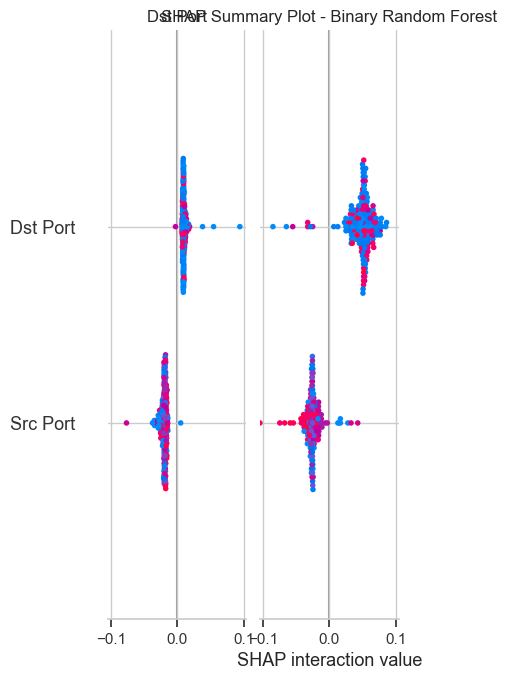

In [10]:
if isinstance(shap_values_binary, list):
    shap.summary_plot(shap_values_binary[1], X_binary_shap, show=False)
else:
    shap.summary_plot(shap_values_binary, X_binary_shap, show=False)
plt.title("SHAP Summary Plot - Binary Random Forest")
plt.show()

15. SHAP for grouped model

In [11]:
X_grouped_shap = X_test_grouped.sample(n=min(300, len(X_test_grouped)), random_state=42)

explainer_grouped = shap.TreeExplainer(grouped_model)
shap_values_grouped = explainer_grouped.shap_values(X_grouped_shap)

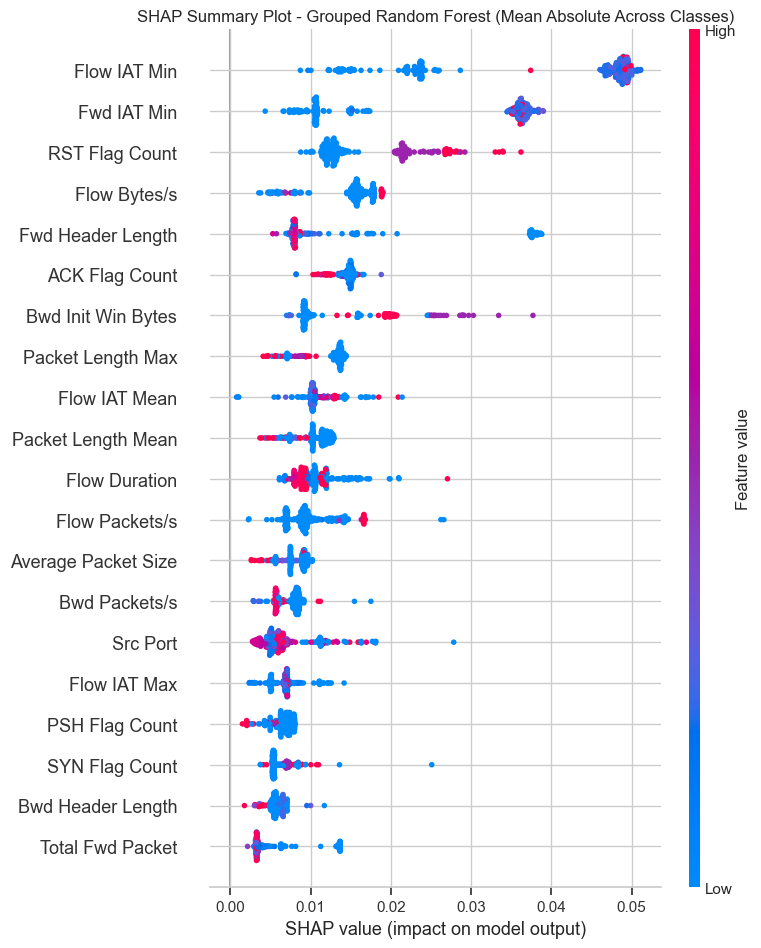

In [12]:
sv = np.array(shap_values_grouped)

if isinstance(shap_values_grouped, list):
    shap_abs_mean = np.mean([np.abs(v) for v in shap_values_grouped], axis=0)
elif sv.ndim == 3:
    shap_abs_mean = np.mean(np.abs(sv), axis=2)
else:
    shap_abs_mean = np.abs(sv)

shap.summary_plot(shap_abs_mean, X_grouped_shap, show=False)
plt.title("SHAP Summary Plot - Grouped Random Forest (Mean Absolute Across Classes)")
plt.show()

16. SHAP for full multiclass model

In [13]:
X_full_shap = X_test_full.sample(n=min(200, len(X_test_full)), random_state=42)

explainer_full = shap.TreeExplainer(full_model)
shap_values_full = explainer_full.shap_values(X_full_shap)

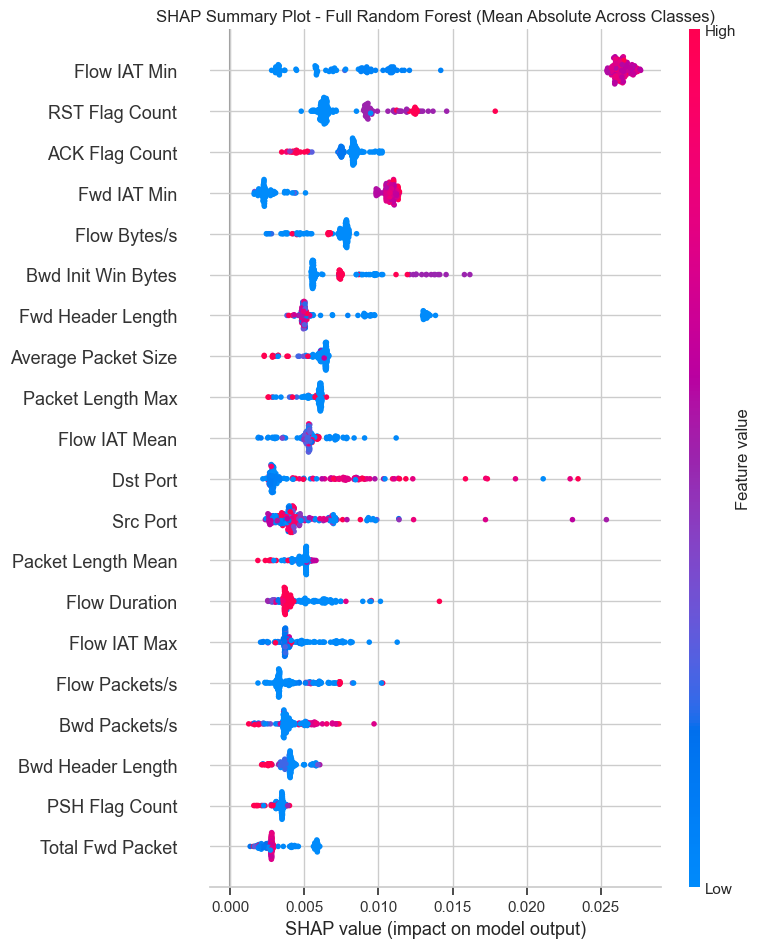

In [14]:
sv_full = np.array(shap_values_full)

if isinstance(shap_values_full, list):
    shap_abs_mean_full = np.mean([np.abs(v) for v in shap_values_full], axis=0)
elif sv_full.ndim == 3:
    shap_abs_mean_full = np.mean(np.abs(sv_full), axis=2)
else:
    shap_abs_mean_full = np.abs(sv_full)

shap.summary_plot(shap_abs_mean_full, X_full_shap, show=False)
plt.title("SHAP Summary Plot - Full Random Forest (Mean Absolute Across Classes)")
plt.show()

17. Local explanation example - binary model

## Local explanation example - Binary prediction
This section examines one individual prediction from the binary Random Forest.

In [15]:
sample_idx = X_binary_shap.index[0]
single_row = X_test_binary.loc[[sample_idx]]
single_true = y_test_binary.loc[sample_idx]
single_pred = binary_model.predict(single_row)[0]
single_proba = binary_model.predict_proba(single_row)[0]

print("True label:", single_true)
print("Predicted label:", single_pred)
print("Predicted probabilities:", single_proba)

True label: 1
Predicted label: 1
Predicted probabilities: [0. 1.]


In [16]:
try:
    shap.force_plot(
        explainer_binary.expected_value[1] if isinstance(explainer_binary.expected_value, (list, np.ndarray)) else explainer_binary.expected_value,
        shap_values_binary[1][0] if isinstance(shap_values_binary, list) else shap_values_binary[0],
        single_row,
        matplotlib=True,
        show=False
    )
    plt.title("Local SHAP Explanation - Binary Random Forest")
    plt.show()
except:
    print("Force plot rendering skipped. SHAP values were computed successfully.")

Force plot rendering skipped. SHAP values were computed successfully.


18. Error-focused analysis for binary model

## Error-focused binary analysis
This section inspects a subset of binary misclassifications.

In [17]:
y_pred_binary = binary_model.predict(X_test_binary)
binary_errors = X_test_binary.copy()
binary_errors["true_label"] = y_test_binary.values
binary_errors["predicted_label"] = y_pred_binary
binary_errors["is_error"] = (binary_errors["true_label"] != binary_errors["predicted_label"]).astype(int)

binary_errors["is_error"].value_counts()

is_error
0    676630
1       433
Name: count, dtype: int64

In [18]:
error_cases = binary_errors[binary_errors["is_error"] == 1].copy()
error_cases.head()

,Src Port,Dst Port,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,true_label,predicted_label,is_error
278,1883,51010,1804,3,0,2894.0,0.0,1436.0,22.0,964.666667,816.373281,0.0,0.0,0.000000,0.000000,1.604213e+06,1662.971175,9.020000e+02,1.264307e+03,1796.0,8.0,1804.0,9.020000e+02,1.264307e+03,1796.0,8.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,60,0,1662.971175,0.000000,22.0,1436.0,1082.500000,707.000000,499849.000000,0,0,0,1,3,0,0,0,0.0,1443.333333,964.666667,0.000000,0,0,0,0,0,0,0,31088,0,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1
759,42464,443,1436332,15,14,959.0,5363.0,517.0,0.0,63.933333,137.206553,1448.0,0.0,383.071429,561.237844,4.401489e+03,20.190318,5.129757e+04,9.613505e+04,470725.0,0.0,1213364.0,8.666886e+04,1.616091e+05,628061.0,0.0,1115085.0,8.577577e+04,1.961714e+05,725260.0,1.0,0,0,488,456,10.443268,9.747050,0.0,1448.0,210.733333,421.077021,177305.857471,2,2,0,13,28,0,0,0,0.0,218.000000,63.933333,383.071429,6322,15,6347,0,0,0,0,65535,114,6,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1
2117,35317,1883,60008628,4,3,4.0,4.0,2.0,0.0,1.000000,1.154701,2.0,0.0,1.333333,1.154701,1.333142e-01,0.116650,1.000144e+07,2.449648e+07,60004675.0,32.0,60008628.0,2.000288e+07,3.464257e+07,60004675.0,1629.0,60006420.0,3.000321e+07,4.243075e+07,60006284.0,136.0,1,0,128,96,0.066657,0.049993,0.0,2.0,1.250000,1.035098,1.071429,0,0,0,4,7,0,0,0,0.0,1.428571,1.000000,1.333333,0,0,0,4,4,3,4,502,64,1,32,1629.0,0.0,1629.0,1629.0,60004675.0,0.0,60004675.0,60004675.0,0,1,1
5261,43792,443,211218,1,5,0.0,474.0,0.0,0.0,0.000000,0.000000,405.0,0.0,94.800000,175.962212,2.244127e+03,28.406670,4.224360e+04,4.259475e+04,88129.0,5.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,179031.0,4.475775e+04,4.875391e+04,88129.0,5.0,0,0,20,160,4.734445,23.672225,0.0,405.0,67.714286,150.935653,22781.571429,1,0,1,2,5,0,0,0,5.0,79.000000,0.000000,94.800000,0,0,0,0,0,0,0,0,135,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
6758,46826,8883,60109435,1,1,31.0,31.0,31.0,31.0,31.000000,0.000000,31.0,31.0,31.000000,0.000000,1.031452e+00,0.033273,6.010944e+07,0.000000e+00,60109435.0,60109435.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,1,0,32,32,0.016636,0.016636,31.0,31.0,31.000000,0.000000,0.000000,0,0,0,2,2,0,0,0,1.0,46.500000,31.000000,31.000000,0,0,0,1,31,1,31,265,265,0,32,0.0,0.0,0.0,0.0,60109435.0,0.0,60109435.0,60109435.0,1,0,1


19. Overall findings table

In [19]:
final_findings = pd.DataFrame({
    "Dimension": [
        "Binary classification difficulty",
        "Grouped multiclass difficulty",
        "Full multiclass difficulty",
        "Best overall model family",
        "Main challenge observed",
        "Key predictive signals",
        "Deployment-ready model"
    ],
    "Finding": [
        "Low - highly separable benign vs attack task",
        "Moderate - rare grouped classes remain challenging",
        "Higher - fine-grained subtype confusion is substantial",
        "Random Forest",
        "Rare-class sparsity and similarity between related attack types",
        "Timing, packet-rate, packet-size, port, and TCP-flag features",
        "Binary and grouped Random Forest models"
    ]
})

final_findings

,Dimension,Finding
0,Binary classification difficulty,Low - highly separable benign vs attack task
1,Grouped multiclass difficulty,Moderate - rare grouped classes remain challen...
2,Full multiclass difficulty,Higher - fine-grained subtype confusion is sub...
3,Best overall model family,Random Forest
4,Main challenge observed,Rare-class sparsity and similarity between rel...
5,Key predictive signals,"Timing, packet-rate, packet-size, port, and TC..."
6,Deployment-ready model,Binary and grouped Random Forest models


20. Final recommendation section

## Final recommendations

Based on the full project workflow, the following deployment strategy is recommended:

1. Use the binary Random Forest model as the primary real-time intrusion detection layer.
2. Use the grouped multiclass Random Forest model as the main attack-family classifier after malicious traffic is detected.
3. Treat the full multiclass Random Forest model as an advanced analytical tool for deeper forensic classification rather than the default operational model.
4. Emphasise macro-level evaluation when discussing multiclass performance, especially under severe class imbalance.
5. Use the Streamlit application to demonstrate practical deployment and interactive model usage in the portfolio.

21. Export explainability outputs

In [38]:
perm_binary_df.to_csv(REPORT_DIR / "binary_permutation_importance.csv", index=False)
perm_grouped_df.to_csv(REPORT_DIR / "grouped_permutation_importance.csv", index=False)
perm_full_df.to_csv(REPORT_DIR / "full_permutation_importance.csv", index=False)

cross_task_summary.to_csv(REPORT_DIR / "cross_task_best_model_summary.csv", index=False)
final_selection_table.to_csv(REPORT_DIR / "final_model_selection_table.csv", index=False)
final_findings.to_csv(REPORT_DIR / "final_findings_table.csv", index=False)

print("Explainability and final summary outputs exported.")

Explainability and final summary outputs exported.


22. Final summary

## Summary of findings

This notebook consolidated the main project findings and confirmed that Random Forest was the strongest model family across all three predictive tasks. The binary intrusion-detection problem proved to be highly separable, while the grouped multiclass task introduced greater difficulty primarily through minority attack families. The full multiclass task was the most challenging, with the main errors occurring among rare and behaviorally similar attack variants.

Feature-importance, permutation-importance, and SHAP-based explanations showed that the models rely heavily on timing behaviour, packet rates, packet size statistics, port-related features, and TCP control-flag patterns. These findings support the credibility of the models and provide interpretable evidence for why the strongest classifiers perform well.

From a deployment perspective, the binary and grouped Random Forest models are the most suitable for the final portfolio application, while the full multiclass model is best presented as an advanced analytical extension.

### Portfolio note
This project demonstrates an end-to-end machine learning workflow for IoMT cybersecurity, including raw data integration, exploratory analysis, preprocessing, imbalanced classification, multiclass evaluation, explainability, and deployment preparation via a Streamlit application.